## Práctica 1: Visualización de grupos en dimensión reducida (Puntos 1 a 3)

En esta libreta se desarrolla de forma completa y coherente:

1. EDA breve del conjunto de datos.
2. Selección y justificación de variables relevantes para marginación municipal.
3. Reducción de dimensionalidad a 2 componentes para visualización e interpretación.


In [7]:
import zipfile
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
pd.set_option('display.max_columns', 200)

zip_path = 'data/M3P1_Metodos_Reduccion.zip'
with zipfile.ZipFile(zip_path) as z:
    censo = pd.read_csv(
        z.open('iter_00_cpv2020/conjunto_de_datos/conjunto_de_datos_iter_00CSV20.csv'),
        low_memory=False
    )

# Convertimos columnas numéricas y preservamos nombres geográficos
for col in censo.columns:
    if col not in ['NOM_ENT', 'NOM_MUN', 'NOM_LOC', 'LONGITUD', 'LATITUD']:
        censo[col] = pd.to_numeric(censo[col], errors='coerce')

# Construcción municipal consolidada:
# LOC=0 (total de localidades ordinarias) + LOC=9998 + LOC=9999
mun_base = censo[
    (censo['ENTIDAD'] > 0) &
    (censo['MUN'] > 0) &
    (censo['LOC'].isin([0, 9998, 9999]))
].copy()

cols_no_suma = {
    'ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN',
    'LOC', 'NOM_LOC', 'LONGITUD', 'LATITUD', 'ALTITUD', 'TAMLOC'
}
cols_suma = [c for c in censo.columns if c not in cols_no_suma]

mun = (
    mun_base
    .groupby(['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN'], as_index=False)[cols_suma]
    .sum(min_count=1)
)

print(f'Registros totales en censo: {censo.shape[0]:,}')
print(f'Registros usados para consolidar municipio (LOC 0, 9998, 9999): {mun_base.shape[0]:,}')
print(f'Municipios consolidados: {mun.shape[0]:,}')
print(f'Variables en tabla municipal: {mun.shape[1]}')

mun[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'POBTOT', 'TVIVPARHAB']].head()

Registros totales en censo: 195,662
Registros usados para consolidar municipio (LOC 0, 9998, 9999): 6,131
Municipios consolidados: 2,469
Variables en tabla municipal: 280


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,POBTOT,TVIVPARHAB
0,1,Aguascalientes,1,Aguascalientes,951537,267129.0
1,1,Aguascalientes,2,Asientos,51896,12642.0
2,1,Aguascalientes,3,Calvillo,58486,15621.0
3,1,Aguascalientes,4,Cosío,17187,3987.0
4,1,Aguascalientes,5,Jesús María,130388,33327.0


### Punto 1. EDA breve

En el análisis exploratorio se revisa:

- Tamaño de población municipal (`POBTOT`) y su asimetría.
- Condición laboral y social con variables agregadas (`PEA`, `POCUPADA`, `PSINDER`).
- Calidad de vivienda con acceso a servicios (`VPH_S_ELEC`, `VPH_NODREN`, `VPH_AGUAFV`).
- Completitud de datos en variables clave para asegurar consistencia analítica.


Resumen estadístico (variables clave):


,count,mean,std,min,25%,50%,75%,max
POBTOT,2469.0,51199.474686,147137.933211,82.0,4539.0,13598.0,35446.0,1923611.0
P_15YMAS,2469.0,38187.372215,113411.194780,70.0,3256.0,9688.0,25047.0,1468256.0
PEA,2469.0,25302.799514,76922.611882,42.0,1683.0,5842.0,16007.0,1052034.0
POCUPADA,2469.0,24832.249494,75469.137623,42.0,1626.0,5754.0,15723.0,1039072.0
PSINDER,2469.0,13422.457270,39644.797938,12.0,833.0,3008.0,9360.0,594796.0
TVIVPARHAB,2469.0,14304.065614,42282.732905,30.0,1237.0,3634.0,9312.0,577041.0
VPH_S_ELEC,2469.0,117.313487,248.115475,0.0,16.0,47.0,121.0,4161.0
VPH_NODREN,2469.0,616.898339,1155.312344,0.0,78.0,235.0,669.0,14845.0
VPH_AGUAFV,2469.0,502.742406,1156.806432,0.0,28.0,122.0,462.0,15776.0
VPH_SINTIC,2469.0,350.343459,652.433872,0.0,56.0,151.0,390.0,15867.0



Porcentaje de datos faltantes por variable (%):


,pct_missing
POBTOT,0.0
P_15YMAS,0.0
PEA,0.0
POCUPADA,0.0
PSINDER,0.0
TVIVPARHAB,0.0
VPH_S_ELEC,0.0
VPH_NODREN,0.0
VPH_AGUAFV,0.0
VPH_SINTIC,0.0


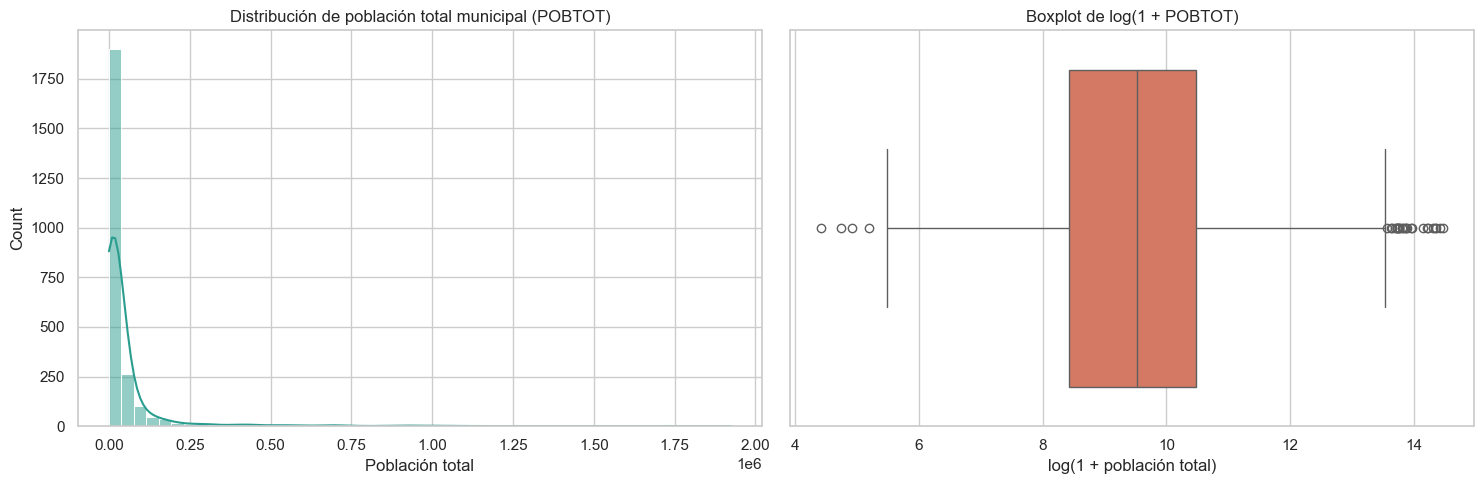

In [8]:
eda_vars = [
    'POBTOT', 'P_15YMAS', 'PEA', 'POCUPADA', 'PSINDER',
    'TVIVPARHAB', 'VPH_S_ELEC', 'VPH_NODREN', 'VPH_AGUAFV', 'VPH_SINTIC'
]

eda = mun[eda_vars].copy()

print('Resumen estadístico (variables clave):')
display(eda.describe(percentiles=[0.25, 0.5, 0.75]).T)

missing = eda.isna().mean().sort_values(ascending=False) * 100
print('\nPorcentaje de datos faltantes por variable (%):')
display(missing.to_frame('pct_missing').round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(mun['POBTOT'], bins=50, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribución de población total municipal (POBTOT)')
axes[0].set_xlabel('Población total')

sns.boxplot(x=np.log1p(mun['POBTOT']), ax=axes[1], color='#e76f51')
axes[1].set_title('Boxplot de log(1 + POBTOT)')
axes[1].set_xlabel('log(1 + población total)')

plt.tight_layout()
plt.show()

### EDA: Clasificación del catálogo (sin usar valores de los datos)

Este bloque clasifica el **diccionario/catálogo oficial** por dominio temático y recomendación de uso en el índice.

Enfoque:

- La clasificación se basa en `Indicador`, `Descripción` y `Mnemónico` del diccionario.
- No se usan correlaciones ni distribuciones para decidir utilidad en esta etapa.
- Se marca por variable: `Usar ahora`, `Agregar bloque candidato`, `Agregar como contexto`, `Usar para segmentar` o `No usar en índice`.

Además, se incorpora el catálogo `tam_loc` para proponer estratificación rural/urbana en el EDA.


In [9]:
import re

with zipfile.ZipFile(zip_path) as z:
    dic_raw = pd.read_csv(
        z.open('iter_00_cpv2020/diccionario_datos/diccionario_datos_iter_00CSV20.csv'),
        header=None,
        low_memory=False
    )
    tam_loc = pd.read_csv(z.open('iter_00_cpv2020/catalogos/tam_loc.csv.csv'))

mask = dic_raw[0].astype(str).str.fullmatch(r'\d+', na=False) & dic_raw[3].notna()
catalogo = dic_raw.loc[mask, [1, 2, 3]].copy()
catalogo.columns = ['Indicador', 'Descripcion', 'Mnemónico']
catalogo['Mnemónico'] = catalogo['Mnemónico'].astype(str).str.strip()
catalogo = catalogo.drop_duplicates(subset='Mnemónico').reset_index(drop=True)

vars_geo = {
    'ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN',
    'LOC', 'NOM_LOC', 'LONGITUD', 'LATITUD', 'ALTITUD', 'TAMLOC'
}

vars_base_ahora = {
    'P15YM_AN', 'P15YM_SE', 'P6A11_NOA', 'P12A14NOA',
    'PSINDER', 'VPH_PISOTI', 'VPH_NODREN', 'VPH_AGUAFV', 'VPH_S_ELEC', 'VPH_SINTIC',
    'P_15YMAS', 'P_6A11', 'P_12A14', 'POBTOT', 'TVIVPARHAB'
}

age_pattern = re.compile(r'^(P_?\d+A\d+|P_?\d+YMAS|P\d+A\d+|POB\d+_\d+)$')


def dominio_catalogo(row):
    var = row['Mnemónico']
    txt = f"{row['Indicador']} {row['Descripcion']}".lower()

    if var in vars_geo:
        return 'Geografía e identificación'

    if 'viviendas particulares habitadas' in txt or var.startswith('VPH_'):
        if any(k in txt for k in ['no disponen de drenaje', 'no disponen de agua entubada', 'no disponen de energía eléctrica', 'piso de tierra']):
            return 'Vivienda y servicios básicos'
        if any(k in txt for k in ['tecnolog', 'internet', 'computadora', 'celular', 'televisión', 'television', 'radio', 'refrigerador', 'lavadora', 'automóvil', 'automovil', 'motocicleta', 'bicicleta']):
            return 'Tecnología y bienes del hogar'
        return 'Condiciones de vivienda'

    if any(k in txt for k in ['analfabeta', 'escolaridad', 'asiste a la escuela', 'primaria', 'secundaria']):
        return 'Educación'

    if any(k in txt for k in ['servicios de salud', 'sin afiliación', 'sin afiliacion', 'afiliada a servicios de salud']):
        return 'Salud y seguridad social'

    if any(k in txt for k in ['económicamente activa', 'economicamente activa', 'ocupada', 'desocupada', 'no económicamente activa', 'no economicamente activa']):
        return 'Actividad económica'

    if any(k in txt for k in ['lengua indígen', 'lengua indig', 'afromexicana', 'afrodescendiente']):
        return 'Población indígena y afrodescendiente'

    if any(k in txt for k in ['discapacidad', 'limitación', 'limitacion']):
        return 'Discapacidad y limitaciones'

    if any(k in txt for k in ['residente en', 'nacida en la entidad', 'nacida en otra entidad']):
        return 'Migración y movilidad'

    if any(k in txt for k in ['católica', 'catolica', 'religión', 'religion', 'estado conyugal', 'hijas e hijos nacidos vivos']):
        return 'Estructura sociodemográfica'

    if var in {'POBTOT', 'POBFEM', 'POBMAS'} or age_pattern.match(var) or var.startswith('P_'):
        return 'Demografía y estructura por edad'

    if any(k in txt for k in ['hogares', 'jefatura', 'hogar']):
        return 'Hogares'

    return 'Otros'


def recomendar_uso(row):
    var = row['Mnemónico']
    dom = row['Dominio']
    is_sexo = var.endswith('_F') or var.endswith('_M')

    if var in vars_base_ahora:
        return ('Usar ahora', 'Variable base directa (numerador/denominador) para construir proporciones comparables.')

    if dom == 'Geografía e identificación':
        return ('No usar en índice', 'Es llave geográfica o referencia espacial; útil para unir/ubicar, no para medir carencia.')

    if dom == 'Demografía y estructura por edad':
        if is_sexo:
            return ('Agregar en análisis específico', 'Desagregación útil para enfoque de edad/sexo, no para el índice base de carencias.')
        return ('Usar para segmentar', 'Aporta composición poblacional para estratificar resultados, no privación directa.')

    if dom in ['Educación', 'Salud y seguridad social', 'Vivienda y servicios básicos']:
        if is_sexo:
            return ('Agregar en análisis específico', 'Indicador relevante, pero su versión por sexo se usa si el objetivo incluye brecha de género.')
        return ('Agregar bloque candidato', 'Dominio estructural de marginación; candidato natural para ampliar el índice.')

    if dom == 'Tecnología y bienes del hogar':
        if var == 'VPH_SINTIC':
            return ('Usar ahora', 'Carencia digital directa incluida en el modelo base.')
        return ('Agregar como contexto', 'Útil para brecha digital/equipamiento; puede complementar, no sustituir carencias básicas.')

    if dom in ['Actividad económica', 'Discapacidad y limitaciones', 'Población indígena y afrodescendiente', 'Migración y movilidad', 'Hogares']:
        return ('Agregar como contexto', 'Puede explicar heterogeneidad territorial; recomendable para extensión del modelo.')

    if dom == 'Estructura sociodemográfica':
        return ('No usar en índice', 'Describe perfil social/cultural; no mide privación material directa en este alcance.')

    return ('Revisar manualmente', 'Sin clasificación robusta automática; requiere revisión de negocio.')


catalogo['Dominio'] = catalogo.apply(dominio_catalogo, axis=1)
catalogo[['Recomendación', 'Justificación']] = catalogo.apply(
    lambda r: pd.Series(recomendar_uso(r)), axis=1
)

print(f'Variables únicas en catálogo: {catalogo.shape[0]:,}')

print('\nResumen por dominio:')
display(catalogo.groupby('Dominio').size().sort_values(ascending=False).rename('n').to_frame())

print('\nResumen por recomendación:')
display(catalogo.groupby('Recomendación').size().sort_values(ascending=False).rename('n').to_frame())

catalogo_clasificado = catalogo[[
    'Mnemónico', 'Indicador', 'Dominio', 'Recomendación', 'Justificación'
]].sort_values(['Recomendación', 'Dominio', 'Mnemónico']).reset_index(drop=True)

print('\nCatálogo clasificado (variable por variable):')
display(catalogo_clasificado)

# Integración del catálogo TAMLOC como estratificador del EDA
tam_loc = tam_loc.copy()

def grupo_tam_loc(code):
    if code <= 4:
        return 'Rural (1 a 2,499 hab)'
    if code <= 8:
        return 'Transición (2,500 a 29,999 hab)'
    return 'Urbano (30,000+ hab)'

tam_loc['grupo_analitico'] = tam_loc['tam_loc'].apply(grupo_tam_loc)

print('\nCatálogo TAMLOC con grupo analítico sugerido:')
display(tam_loc)

# Exportables para trazabilidad del EDA
data_catalogo_out = 'data/eda_catalogo_clasificado.csv'
data_tamloc_out = 'data/eda_catalogo_tamloc_clasificado.csv'
catalogo_clasificado.to_csv(data_catalogo_out, index=False)
tam_loc.to_csv(data_tamloc_out, index=False)

print(f'\nArchivos generados: {data_catalogo_out} y {data_tamloc_out}')


Variables únicas en catálogo: 286

Resumen por dominio:


,n
Dominio,
Demografía y estructura por edad,99
Educación,39
Condiciones de vivienda,31
Tecnología y bienes del hogar,17
Población indígena y afrodescendiente,16
Discapacidad y limitaciones,15
Otros,13
Actividad económica,12
Migración y movilidad,12



Resumen por recomendación:


,n
Recomendación,
Agregar en análisis específico,77
Agregar como contexto,74
Revisar manualmente,43
Usar para segmentar,32
Agregar bloque candidato,31
Usar ahora,15
No usar en índice,14



Catálogo clasificado (variable por variable):


,Mnemónico,Indicador,Dominio,Recomendación,Justificación
0,GRAPROES,Grado promedio de escolaridad,Educación,Agregar bloque candidato,Dominio estructural de marginación; candidato ...
1,P12A14NOAF,Población femenina de 12 a 14 años que no asis...,Educación,Agregar bloque candidato,Dominio estructural de marginación; candidato ...
2,P12A14NOAM,Población masculina de 12 a 14 años que no asi...,Educación,Agregar bloque candidato,Dominio estructural de marginación; candidato ...
3,P15A17A,Población de 15 a 17 años que asiste a la escuela,Educación,Agregar bloque candidato,Dominio estructural de marginación; candidato ...
4,P15PRI_CO,Población de 15 años y más con primaria completa,Educación,Agregar bloque candidato,Dominio estructural de marginación; candidato ...
...,...,...,...,...,...
281,P_70A74,Población de 70 a 74 años,Demografía y estructura por edad,Usar para segmentar,Aporta composición poblacional para estratific...
282,P_75A79,Población de 75 a 79 años,Demografía y estructura por edad,Usar para segmentar,Aporta composición poblacional para estratific...
283,P_80A84,Población de 80 a 84 años,Demografía y estructura por edad,Usar para segmentar,Aporta composición poblacional para estratific...
284,P_85YMAS,Población de 85 años y más,Demografía y estructura por edad,Usar para segmentar,Aporta composición poblacional para estratific...



Catálogo TAMLOC con grupo analítico sugerido:


,tam_loc,descripcion,grupo_analitico
0,1,1 a 249 habitantes,"Rural (1 a 2,499 hab)"
1,2,250 a 499 habitantes,"Rural (1 a 2,499 hab)"
2,3,500 a 999 habitantes,"Rural (1 a 2,499 hab)"
3,4,1 000 a 2 499 habitantes,"Rural (1 a 2,499 hab)"
4,5,2 500 a 4 999 habitantes,"Transición (2,500 a 29,999 hab)"
5,6,5 000 a 9 999 habitantes,"Transición (2,500 a 29,999 hab)"
6,7,10 000 a 14 999 habitantes,"Transición (2,500 a 29,999 hab)"
7,8,15 000 a 29 999 habitantes,"Transición (2,500 a 29,999 hab)"
8,9,30 000 a 49 999 habitantes,"Urbano (30,000+ hab)"
9,10,50 000 a 99 999 habitantes,"Urbano (30,000+ hab)"



Archivos generados: data/eda_catalogo_clasificado.csv y data/eda_catalogo_tamloc_clasificado.csv


### Lectura integrada de la clasificación del catálogo

- La taxonomía por dominio permite sustentar, desde el diccionario oficial, qué variables miden carencias estructurales.
- La selección del Punto 2 incorpora tanto `Usar ahora` como variables relevantes de `Agregar bloque candidato` cuando tienen denominadores sólidos para construir tasas.
- El resultado es un conjunto analítico ampliado, comparable entre municipios y alineado con el objetivo de marginación.


### Hallazgos clave del Punto 1

- La distribución de `POBTOT` es altamente asimétrica: pocos municipios concentran mucha población.
- Existe heterogeneidad marcada entre municipios en condiciones de vivienda y acceso a servicios.
- El conjunto municipal es utilizable para modelado al tener bajo porcentaje de faltantes en variables principales.


### Punto 2. Variables seleccionadas para marginación y justificación

La selección final usa dos bloques del catálogo clasificado:

- **Usar ahora**: variables núcleo de carencia educativa, salud y vivienda.
- **Agregar bloque candidato**: variables adicionales estructurales que se transforman a tasas comparables.

Todas las variables se expresan en **porcentaje** para evitar sesgo por tamaño municipal.


Ficha técnica de variables usadas en el modelo:


,Variable_artificial,Numerador,Denominador,Sentido,Origen_catalogo,Recomendacion_numerador_catalogo
0,pct_analfabetismo_15ymas,P15YM_AN,P_15YMAS,directo,Usar ahora,Usar ahora
1,pct_sin_escolaridad_15ymas,P15YM_SE,P_15YMAS,directo,Usar ahora,Usar ahora
2,pct_no_asiste_6a11,P6A11_NOA,P_6A11,directo,Usar ahora,Usar ahora
3,pct_no_asiste_12a14,P12A14NOA,P_12A14,directo,Usar ahora,Usar ahora
4,pct_sin_derechohab,PSINDER,POBTOT,directo,Usar ahora,Usar ahora
5,pct_piso_tierra,VPH_PISOTI,TVIVPARHAB,directo,Usar ahora,Usar ahora
6,pct_sin_drenaje,VPH_NODREN,TVIVPARHAB,directo,Usar ahora,Usar ahora
7,pct_sin_agua_entubada,VPH_AGUAFV,TVIVPARHAB,directo,Usar ahora,Usar ahora
8,pct_sin_electricidad,VPH_S_ELEC,TVIVPARHAB,directo,Usar ahora,Usar ahora
9,pct_sin_tic,VPH_SINTIC,TVIVPARHAB,directo,Usar ahora,Usar ahora


Municipios con información completa para modelado: 2,469
Resumen estadístico de variables artificiales (%):


,mean,std,min,50%,max
pct_analfabetismo_15ymas,10.19,7.64,0.35,8.25,53.13
pct_sin_escolaridad_15ymas,9.52,6.71,0.52,7.88,49.96
pct_no_asiste_6a11,4.11,2.75,0.00,3.65,38.83
pct_no_asiste_12a14,10.90,6.51,0.00,9.47,57.73
pct_sin_derechohab,24.16,10.82,1.04,22.68,83.71
pct_piso_tierra,8.05,8.86,0.00,4.84,66.98
pct_sin_drenaje,13.93,19.25,0.00,6.12,99.10
pct_sin_agua_entubada,6.37,9.13,0.00,2.85,78.60
pct_sin_electricidad,1.97,3.02,0.00,1.26,51.20
pct_sin_tic,7.30,8.82,0.00,3.98,60.74


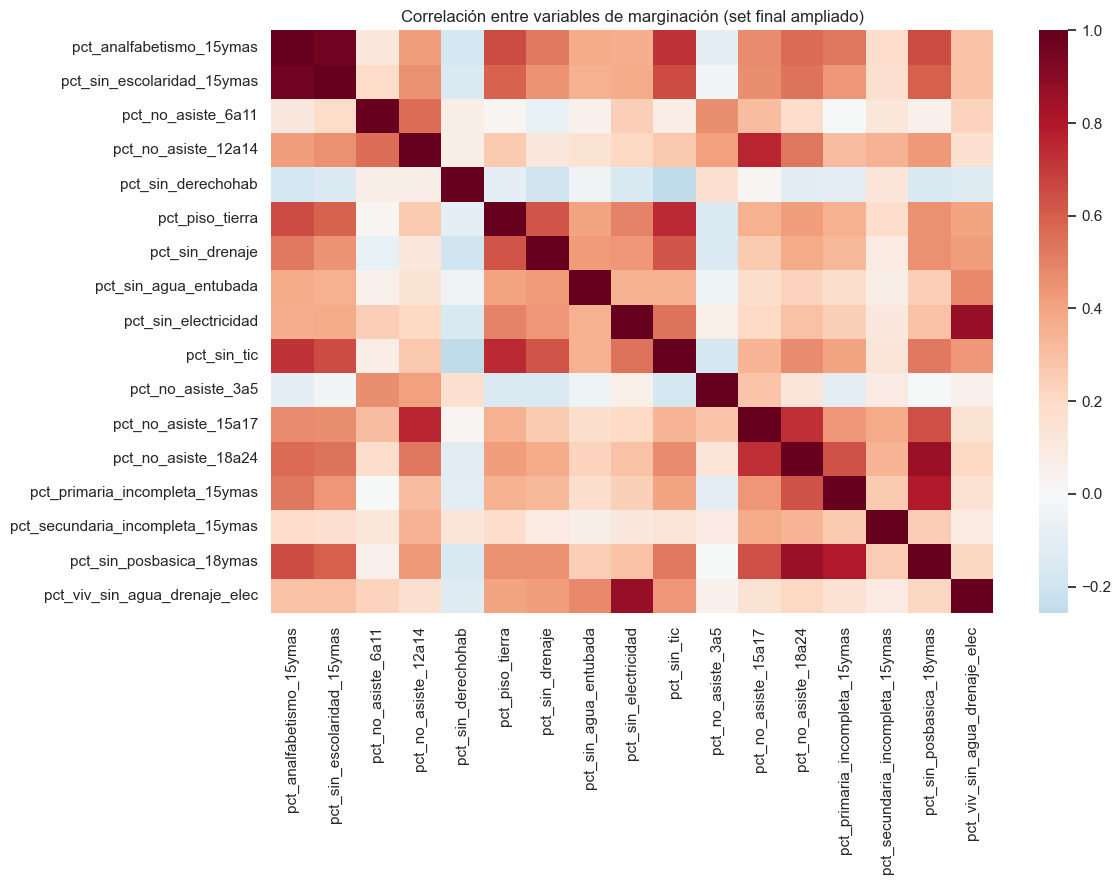

Municipios con mayor promedio de carencias del set final (%):


,NOM_ENT,NOM_MUN,promedio_carencias_pct
213,Chihuahua,Batopilas de Manuel Gómez Morín,47.39
103,Chiapas,Chalchihuitán,41.21
451,Guerrero,Cochoapa el Grande,40.75
163,Chiapas,Sitalá,39.61
217,Chihuahua,Carichí,39.14
302,Durango,Mezquital,38.02
1024,Oaxaca,Coicoyán de las Flores,37.71
1179,Oaxaca,San José Tenango,37.23
270,Chihuahua,Urique,36.86
946,Nayarit,Del Nayar,36.49


In [10]:
analisis_mun = mun.copy()


def agregar_tasa(df, numerador, denominador, nombre, sentido='directo'):
    tasa = 100 * df[numerador] / df[denominador]
    if sentido == 'inverso':
        tasa = 100 - tasa
    df[nombre] = tasa


# Set final de variables artificiales:
# - Núcleo (Usar ahora)
# - Ampliación (Agregar bloque candidato)
especificaciones = [
    # Núcleo
    ('pct_analfabetismo_15ymas', 'P15YM_AN', 'P_15YMAS', 'directo', 'Usar ahora'),
    ('pct_sin_escolaridad_15ymas', 'P15YM_SE', 'P_15YMAS', 'directo', 'Usar ahora'),
    ('pct_no_asiste_6a11', 'P6A11_NOA', 'P_6A11', 'directo', 'Usar ahora'),
    ('pct_no_asiste_12a14', 'P12A14NOA', 'P_12A14', 'directo', 'Usar ahora'),
    ('pct_sin_derechohab', 'PSINDER', 'POBTOT', 'directo', 'Usar ahora'),
    ('pct_piso_tierra', 'VPH_PISOTI', 'TVIVPARHAB', 'directo', 'Usar ahora'),
    ('pct_sin_drenaje', 'VPH_NODREN', 'TVIVPARHAB', 'directo', 'Usar ahora'),
    ('pct_sin_agua_entubada', 'VPH_AGUAFV', 'TVIVPARHAB', 'directo', 'Usar ahora'),
    ('pct_sin_electricidad', 'VPH_S_ELEC', 'TVIVPARHAB', 'directo', 'Usar ahora'),
    ('pct_sin_tic', 'VPH_SINTIC', 'TVIVPARHAB', 'directo', 'Usar ahora'),

    # Ampliación desde catálogo
    ('pct_no_asiste_3a5', 'P3A5_NOA', 'P_3A5', 'directo', 'Agregar bloque candidato'),
    ('pct_no_asiste_15a17', 'P15A17A', 'P_15A17', 'inverso', 'Agregar bloque candidato'),
    ('pct_no_asiste_18a24', 'P18A24A', 'P_18A24', 'inverso', 'Agregar bloque candidato'),
    ('pct_primaria_incompleta_15ymas', 'P15PRI_IN', 'P_15YMAS', 'directo', 'Agregar bloque candidato'),
    ('pct_secundaria_incompleta_15ymas', 'P15SEC_IN', 'P_15YMAS', 'directo', 'Agregar bloque candidato'),
    ('pct_sin_posbasica_18ymas', 'P18YM_PB', 'P_18YMAS', 'inverso', 'Agregar bloque candidato'),
    ('pct_viv_sin_agua_drenaje_elec', 'VPH_NDEAED', 'TVIVPARHAB', 'directo', 'Agregar bloque candidato'),
]

for nombre, num, den, sentido, _ in especificaciones:
    agregar_tasa(analisis_mun, num, den, nombre, sentido=sentido)

vars_marginacion = [x[0] for x in especificaciones]

ficha_variables = pd.DataFrame(especificaciones, columns=[
    'Variable_artificial', 'Numerador', 'Denominador', 'Sentido', 'Origen_catalogo'
])

reco = catalogo.set_index('Mnemónico')['Recomendación'].to_dict()
ficha_variables['Recomendacion_numerador_catalogo'] = ficha_variables['Numerador'].map(reco)

print('Ficha técnica de variables usadas en el modelo:')
display(ficha_variables)

modelo_df = analisis_mun[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN'] + vars_marginacion].replace([np.inf, -np.inf], np.nan).dropna().copy()
print(f'Municipios con información completa para modelado: {modelo_df.shape[0]:,}')

resumen = modelo_df[vars_marginacion].describe().T[['mean', 'std', 'min', '50%', 'max']].round(2)
print('Resumen estadístico de variables artificiales (%):')
display(resumen)

plt.figure(figsize=(12, 9))
corr = modelo_df[vars_marginacion].corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False)
plt.title('Correlación entre variables de marginación (set final ampliado)')
plt.tight_layout()
plt.show()

modelo_df['promedio_carencias_pct'] = modelo_df[vars_marginacion].mean(axis=1)
top_carencias = modelo_df.sort_values('promedio_carencias_pct', ascending=False)[
    ['NOM_ENT', 'NOM_MUN', 'promedio_carencias_pct']
].head(10)
print('Municipios con mayor promedio de carencias del set final (%):')
display(top_carencias.round(2))

### Hallazgos clave del Punto 2

- La selección final integra variables núcleo y variables candidatas del catálogo con transformación a tasas comparables.
- El set ampliado representa con mayor detalle privaciones educativas y de vivienda de alta severidad.
- El patrón de correlaciones confirma coherencia conceptual entre carencias estructurales y permite reducción de dimensionalidad informativa.


### Punto 3. Reducción de dimensionalidad a 2 dimensiones

La proyección se realiza con el **set final ampliado** de variables de marginación:

- **PCA** para síntesis lineal de la varianza.
- **t-SNE** para estructura local no lineal.

Las visualizaciones permiten interpretar agrupamientos municipales en un espacio de carencias comparable.


Varianza explicada por PC1: 0.3856
Varianza explicada por PC2: 0.1441
Varianza explicada acumulada (2 componentes): 0.5298
Cargas PCA (ordenadas por contribución absoluta en PC1):


,PC1,PC2
pct_analfabetismo_15ymas,0.332,-0.073
pct_sin_escolaridad_15ymas,0.317,-0.026
pct_sin_posbasica_18ymas,0.317,0.087
pct_sin_tic,0.309,-0.216
pct_no_asiste_18a24,0.306,0.193
pct_piso_tierra,0.291,-0.197
pct_no_asiste_15a17,0.266,0.345
pct_primaria_incompleta_15ymas,0.256,0.048
pct_sin_drenaje,0.255,-0.269
pct_sin_electricidad,0.234,-0.171


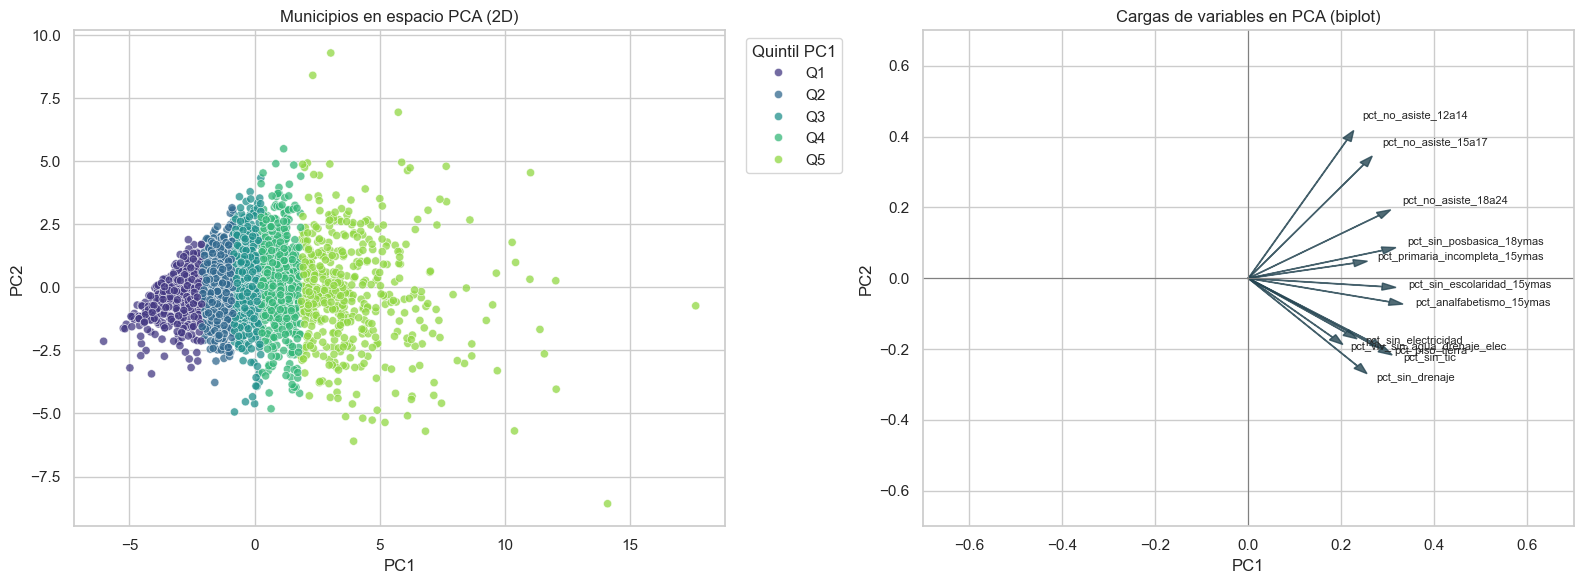

In [11]:
X = modelo_df[vars_marginacion].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = modelo_df[['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN']].copy()
pca_df['PC1'] = X_pca[:, 0]
pca_df['PC2'] = X_pca[:, 1]
pca_df['quintil_pc1'] = pd.qcut(pca_df['PC1'], 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada por PC1: {var_exp[0]:.4f}')
print(f'Varianza explicada por PC2: {var_exp[1]:.4f}')
print(f'Varianza explicada acumulada (2 componentes): {var_exp.sum():.4f}')

loadings = pd.DataFrame(
    pca.components_.T,
    index=vars_marginacion,
    columns=['PC1', 'PC2']
)

print('Cargas PCA (ordenadas por contribución absoluta en PC1):')
display(loadings.sort_values('PC1', key=np.abs, ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='quintil_pc1',
    palette='viridis',
    alpha=0.75,
    s=35,
    ax=axes[0]
)
axes[0].set_title('Municipios en espacio PCA (2D)')
axes[0].legend(title='Quintil PC1', bbox_to_anchor=(1.02, 1), loc='upper left')

# Biplot simplificado con variables de mayor peso en PC1 para legibilidad
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axvline(0, color='gray', lw=0.8)
vars_biplot = loadings['PC1'].abs().sort_values(ascending=False).head(12).index
for var in vars_biplot:
    x = loadings.loc[var, 'PC1']
    y = loadings.loc[var, 'PC2']
    axes[1].arrow(0, 0, x, y, color='#264653', alpha=0.8, head_width=0.02, length_includes_head=True)
    axes[1].text(x * 1.08, y * 1.08, var, fontsize=8)

axes[1].set_xlim(-0.7, 0.7)
axes[1].set_ylim(-0.7, 0.7)
axes[1].set_title('Cargas de variables en PCA (biplot)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

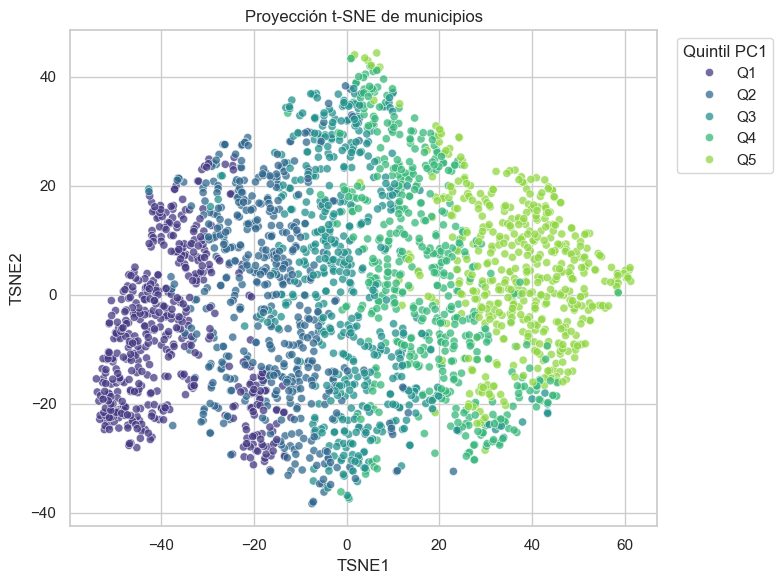

In [12]:
# t-SNE para visualizar estructura no lineal

tsne = TSNE(
    n_components=2,
    random_state=42,
    init='pca',
    learning_rate='auto',
    perplexity=35
)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = modelo_df[['NOM_ENT', 'NOM_MUN']].copy()
tsne_df['TSNE1'] = X_tsne[:, 0]
tsne_df['TSNE2'] = X_tsne[:, 1]
tsne_df['quintil_pc1'] = pca_df['quintil_pc1'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tsne_df,
    x='TSNE1',
    y='TSNE2',
    hue='quintil_pc1',
    palette='viridis',
    alpha=0.75,
    s=35
)
plt.title('Proyección t-SNE de municipios')
plt.legend(title='Quintil PC1', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Hallazgos clave del Punto 3

- La proyección PCA en 2 componentes sintetiza de forma clara la estructura conjunta de carencias municipales.
- Las mayores cargas en PC1 se asocian con rezago educativo y privaciones habitacionales, consolidando un eje interpretable de marginación.
- t-SNE confirma vecindades de municipios con perfiles socioeconómicos similares y refuerza la consistencia del patrón observado en PCA.
